# Modelos computacionales y validación

En ciencias de la Tierra y geoquímica muchos procesos naturales se describen mediante **ecuaciones diferenciales**.  

Estas ecuaciones raramente tienen soluciones analíticas simples, por lo que es necesario resolverlas mediante **métodos numéricos**.

En este notebook estudiaremos un modelo simple de decaimiento químico y compararemos diferentes métodos numéricos para resolverlo.

El objetivo es:

- Implementar un modelo matemático
- Resolverlo con diferentes métodos numéricos
- Comparar las soluciones
- Analizar los errores del modelo

Este ejercicio ilustra cómo funcionan los **modelos computacionales** en ciencia.

## 1. Modelo de decaimiento químico

Consideremos una reacción simple:

A → productos

La velocidad de reacción es proporcional a la concentración de $A$:

$\frac{dC}{dt} = -kC$

donde

C = concentración  
k = constante de reacción

La solución analítica de esta ecuacion es:

$C(t) = C_0 e^{-kt}$

Esta solución nos permitirá **validar los métodos numéricos**.

In [14]:
# Datos de inicializacion

import numpy as np
import matplotlib.pyplot as plt

k = 0.5
C0 = 1.0

t0 = 0
tf = 10
dt = 0.5

t = np.arange(t0, tf+dt, dt)

### Solucion analitica

En este caso vasta con implementar directamente la funcion de la ecuacion (1) y dar el valor exacto de la concentracion a medida que aumenta el tiempo. 

In [15]:
def analytic_solution(t, C0, k):
    return C0*np.exp(-k*t)

C_exact = analytic_solution(t, C0, k)

### Método de Euler

El método de Euler es el método numérico más simple para resolver ecuaciones diferenciales.

La ecuación diferencial a resolver es:

$$
\frac{dC}{dt} = -kC
$$

La derivada puede aproximarse mediante una diferencia finita:

$$
\frac{dC}{dt} \approx \frac{C_{i+1} - C_i}{\Delta t}
$$

Sustituyendo en la ecuación diferencial:

$$
\frac{C_{i+1} - C_i}{\Delta t} = -kC_i
$$

Despejando:

$$
C_{i+1} = C_i + \Delta t(-kC_i)
$$

Este método utiliza la **pendiente en el punto actual** para estimar el siguiente valor.

![Diagrama de modelo](Euler_method.svg.png)

### Interpretación geométrica

El método de Euler aproxima la solución mediante **segmentos de recta** usando la pendiente local.


### Ventajas

- simple de implementar
- rápido

### Desventajas

- errores relativamente grandes
- puede ser inestable para pasos de tiempo grandes

In [16]:
# Implementacion del Euler method

def euler_method(C0, k, t, dt):

    C = np.zeros(len(t))
    C[0] = C0

    for i in range(len(t)-1):

        dCdt = -k*C[i]

        C[i+1] = C[i] + dt*dCdt

    return C

C_euler = euler_method(C0, k, t, dt)

### Método Runge–Kutta de cuarto orden aplicado a este modelo

Recordemos que nuestro modelo es

$$
\frac{dC}{dt} = -kC
$$

Esto significa que la función de la ecuación diferencial es

$$
f(C,t) = -kC
$$

El método Runge–Kutta de cuarto orden (RK4) calcula varias estimaciones de la pendiente dentro del intervalo de tiempo $\Delta t$.

Primero se calcula una pendiente inicial:

$$
k_1 = f(C_i,t_i)
$$

Luego se calcula una pendiente en el punto medio usando $k_1$:

$$
k_2 = f\left(C_i + \frac{\Delta t}{2}k_1,\, t_i+\frac{\Delta t}{2}\right)
$$

Después se calcula otra pendiente en el punto medio usando $k_2$:

$$
k_3 = f\left(C_i + \frac{\Delta t}{2}k_2,\, t_i+\frac{\Delta t}{2}\right)
$$

Finalmente se calcula una pendiente al final del intervalo:

$$
k_4 = f(C_i + \Delta t k_3,\, t_i+\Delta t)
$$

---

### Aplicándolo a nuestra ecuación

Como

$$
f(C,t) = -kC
$$

las expresiones quedan:

$$
k_1 = -kC_i
$$

$$
k_2 = -k\left(C_i + \frac{\Delta t}{2}k_1\right)
$$

$$
k_3 = -k\left(C_i + \frac{\Delta t}{2}k_2\right)
$$

$$
k_4 = -k\left(C_i + \Delta t\,k_3\right)
$$

---

### Actualización de la solución

La concentración en el siguiente paso se calcula como

$$
C_{i+1} =
C_i +
\frac{\Delta t}{6}
\left(k_1 + 2k_2 + 2k_3 + k_4\right)
$$

---

### Interpretación

El método RK4 utiliza un **promedio ponderado de cuatro pendientes** dentro del intervalo de tiempo $\Delta t$.

Esto permite aproximar mucho mejor la solución real de la ecuación diferencial que el método de Euler, que solo usa una pendiente.

In [17]:
def rk4_method(C0, k, t, dt):

    C = np.zeros(len(t))
    C[0] = C0

    for i in range(len(t)-1):

        k1 = -k*C[i]
        k2 = -k*(C[i] + dt*k1/2)
        k3 = -k*(C[i] + dt*k2/2)
        k4 = -k*(C[i] + dt*k3)

        C[i+1] = C[i] + dt*(k1 + 2*k2 + 2*k3 + k4)/6

    return C

C_rk4 = rk4_method(C0, k, t, dt)

### Comparacion de metodos

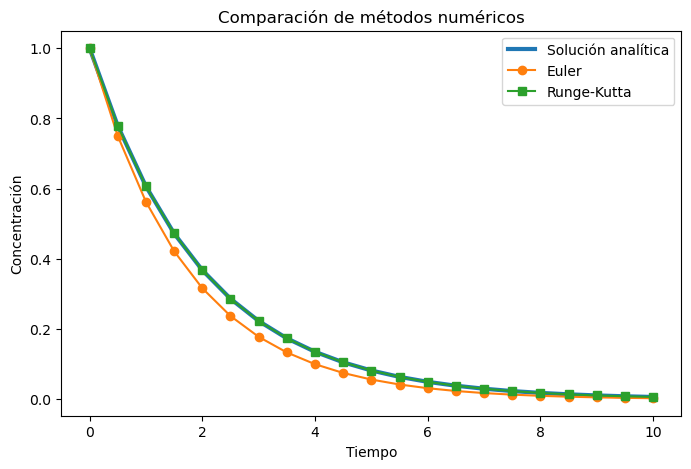

In [18]:
plt.figure(figsize=(8,5))

plt.plot(t, C_exact, label="Solución analítica", linewidth=3)
plt.plot(t, C_euler, 'o-', label="Euler")
plt.plot(t, C_rk4, 's-', label="Runge-Kutta")

plt.xlabel("Tiempo")
plt.ylabel("Concentración")

plt.legend()
plt.title("Comparación de métodos numéricos")

plt.show()

### Error en los diferentes metodos y calculo de RMSE

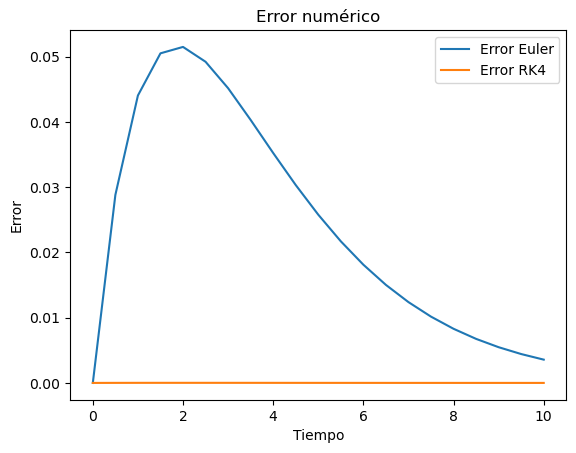

In [19]:
error_euler = np.abs(C_exact - C_euler)
error_rk4 = np.abs(C_exact - C_rk4)

plt.plot(t, error_euler, label="Error Euler")
plt.plot(t, error_rk4, label="Error RK4")

plt.xlabel("Tiempo")
plt.ylabel("Error")

plt.legend()
plt.title("Error numérico")

plt.show()

In [20]:
def rmse(y_true, y_model):

    return np.sqrt(np.mean((y_true-y_model)**2))

print("RMSE Euler =", rmse(C_exact, C_euler))
print("RMSE RK4 =", rmse(C_exact, C_rk4))

RMSE Euler = 0.02954447911959464
RMSE RK4 = 8.743415005389709e-06


## Preguntas

1. ¿Cuál método reproduce mejor la solución analítica?
R/: Runge-kutta
2. ¿Qué ocurre si aumentamos el paso temporal $\Delta t$?
R/: 
3. ¿Por qué el método de Euler presenta mayor error?
R/: Porque solo se basa en un solo dato por ende omite muchos errores 
4. ¿Qué implicaciones tiene esto para modelos geoquímicos complejos?
R/:
5. ¿Por qué es importante validar los modelos computacionales?
R/: 

## Problema 1. Ejercicio de análisis numérico

En el modelo implementado anteriormente, el paso temporal $\Delta t$ controla la resolución temporal del método numérico.

1. Modifique el valor del paso temporal en el código y ejecute nuevamente las simulaciones para los siguientes valores:

$$
\Delta t = 2
$$

$$
\Delta t = 1
$$

$$
\Delta t = 0.1
$$

2. Para cada valor de $\Delta t$:

- Grafique la solución obtenida con los métodos de **Euler** y **Runge–Kutta (RK4)**.
- Compare cada solución con la **solución analítica**.

3. Calcule el **error cuadrático medio (RMSE)** para cada método y cada valor de $\Delta t$.

4. Con base en los resultados obtenidos, responda:

a) ¿Cómo cambia el error numérico cuando el paso temporal $\Delta t$ aumenta o disminuye?

b) ¿Cuál de los dos métodos muestra mayor estabilidad y precisión?

c) ¿Qué implicaciones tiene el tamaño del paso temporal en la construcción de modelos computacionales para sistemas geoquímicos?

## Problema 2: Disolución de calcita en sistemas acuosos

La calcita ($CaCO_3$) es uno de los minerales más abundantes en sistemas naturales y juega un papel fundamental en la geoquímica del carbono, en la química de aguas naturales y en procesos de meteorización.

La disolución de calcita ocurre cuando el mineral entra en contacto con agua que no está en equilibrio con el carbonato de calcio. Este proceso es especialmente importante en ambientes donde el agua contiene dióxido de carbono disuelto o presenta valores de pH relativamente bajos.

---

### Reacción de disolución

La reacción global de disolución de calcita en presencia de protones puede escribirse como

$$
CaCO_3(s) + H^+ \rightarrow Ca^{2+} + HCO_3^-
$$

En esta reacción:

- el mineral sólido libera calcio al agua
- el carbonato se transforma en bicarbonato
- los protones favorecen la disolución del mineral

Por esta razón, la velocidad de disolución de calcita depende fuertemente del **pH del sistema**.

---

### Cinética de disolución

La velocidad de disolución de minerales suele describirse mediante leyes cinéticas que dependen de la distancia al equilibrio químico.

Una forma simplificada de la ley cinética para calcita es

$$
\frac{dC}{dt} = k_H [H^+] (1-\Omega)
$$

donde

- $r$ es la velocidad de reacción
- $k_H$ es una constante cinética
- $[H^+]$ es la concentración de protones
- $\Omega$ es el índice de saturación del mineral

---

### Índice de saturación

El índice de saturación mide qué tan lejos está la solución del equilibrio con el mineral.

Se define como

$$
\Omega = \frac{IAP}{K_{sp}}
$$

donde

- $IAP$ es el **producto iónico**
- $K_{sp}$ es la **constante de solubilidad del mineral**

El comportamiento del sistema depende de $\Omega$:

| Condición | Significado |
|-----------|-------------|
| $\Omega < 1$ | el mineral se disuelve |
| $\Omega = 1$ | equilibrio químico |
| $\Omega > 1$ | el mineral precipita |

---

### Aproximación simplificada

Para simplificar el problema, supondremos que el índice de saturación depende únicamente de la concentración de calcio en solución:

$$
\Omega = \frac{C}{C_{eq}}
$$

donde

- $C$ es la concentración de calcio en solución
- $C_{eq}$ es la concentración de equilibrio.

Sustituyendo esta expresión en la ley cinética obtenemos

$$
\frac{dC}{dt} =
k_H [H^+] \left(1-\frac{C}{C_{eq}}\right)
$$

---

### Relación entre pH y concentración de protones

La concentración de protones está relacionada con el pH mediante

$$
[H^+] = 10^{-pH}
$$

Por lo tanto, el modelo final se puede escribir como

$$
\frac{dC}{dt} =
k_H 10^{-pH}
\left(1-\frac{C}{C_{eq}}\right)
$$

---

### Interpretación física del modelo

Este modelo describe tres comportamientos importantes:

1. **Dependencia del pH**

A pH bajos la concentración de protones es mayor y la disolución ocurre más rápidamente.

2. **Efecto del equilibrio**

A medida que la concentración de calcio aumenta, el sistema se aproxima al equilibrio químico y la velocidad de reacción disminuye.

3. **Estado final del sistema**

Cuando

$$
C \rightarrow C_{eq}
$$

la velocidad de disolución tiende a cero y el sistema alcanza el equilibrio.

---

### Objetivo del modelo computacional

En este ejercicio utilizaremos métodos numéricos para resolver la ecuación diferencial que describe la evolución temporal de la concentración de calcio durante la disolución de calcita.

## Problema 2: Disolución de calcita dependiente del pH

La disolución de calcita puede describirse mediante el modelo

$$
\frac{dC}{dt} =
k_H 10^{-pH}
\left(1-\frac{C}{C_{eq}}\right)
$$

donde

- $C$ es la concentración de calcio en solución
- $k_H$ es una constante cinética
- $C_{eq}$ es la concentración de equilibrio

---

### Parámetros

$$
k_H = 5\times10^3
$$

$$
C_{eq} = 2\times10^{-3}
$$

$$
C(0)=0
$$

---

### Actividades

1. Implemente el modelo usando

- método de Euler
- método Runge–Kutta de cuarto orden

2. Simule la evolución de $C(t)$ para

- $pH = 5$
- $pH = 6$
- $pH = 7$

3. Grafique los resultados.

4. Compare las curvas obtenidas y responda:

a) ¿Cómo afecta el pH la velocidad de disolución de calcita?

b) ¿Por qué la disolución es más rápida a pH bajos?

c) ¿Qué ocurre cuando $C$ se aproxima a $C_{eq}$?

5. Analice el efecto del paso temporal $\Delta t$ en la estabilidad del modelo.

In [88]:
import numpy as np
import matplotlib.pyplot as plt

kH = 5e3
Ceq = 2e-3

C0 = 0

In [89]:
def dCdt(C, pH):

    rate = kH * 10**(-pH)

    return rate * (1 - C/Ceq)

In [90]:
def euler_step(C, dt, pH):

    return C + dt*dCdt(C,pH)

In [91]:
def rk4_step(C, dt, pH):

    k1 = dCdt(C,pH)

    k2 = dCdt(C + 0.5*dt*k1, pH)

    k3 = dCdt(C + 0.5*dt*k2, pH)

    k4 = dCdt(C + dt*k3, pH)

    return C + dt*(k1 + 2*k2 + 2*k3 + k4)/6

In [97]:
dt = 0.01
tmax = 5

steps = int(tmax/dt)

time = np.linspace(0,tmax,steps)

pH_values = [5,7,8]

In [98]:
results_euler = {}

for pH in pH_values:

    C = C0
    C_values = []

    for i in range(steps):

        C = euler_step(C,dt,pH)

        C_values.append(C)

    results_euler[pH] = np.array(C_values)

In [99]:
results_rk4 = {}

for pH in pH_values:

    C = C0
    C_values = []

    for i in range(steps):

        C = rk4_step(C,dt,pH)

        C_values.append(C)

    results_rk4[pH] = np.array(C_values)

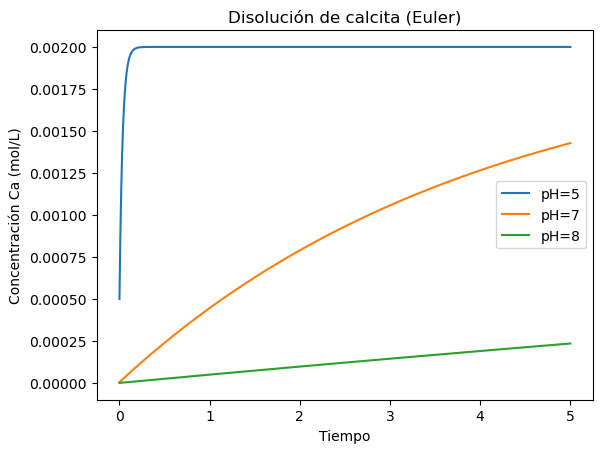

In [100]:
plt.figure()

for pH in pH_values:

    plt.plot(time, results_euler[pH], label=f"pH={pH}")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (Euler)")

plt.legend()
plt.show()

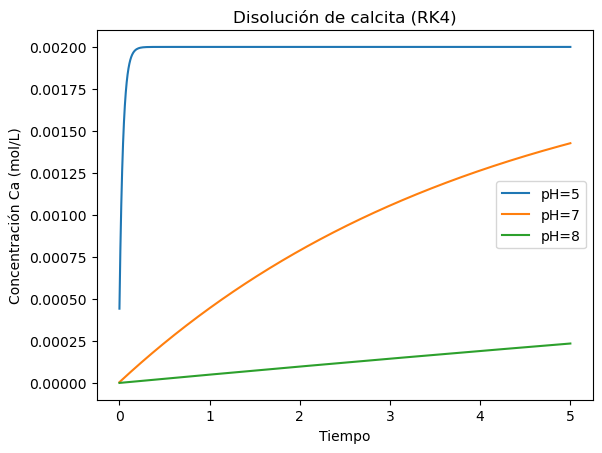

In [101]:
plt.figure()

for pH in pH_values:

    plt.plot(time, results_rk4[pH], label=f"pH={pH}")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (RK4)")

plt.legend()
plt.show()

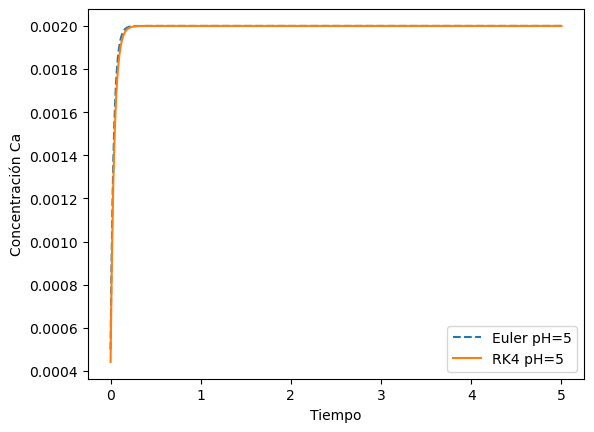

In [87]:
plt.figure()

plt.plot(time, results_euler[5], '--', label="Euler pH=5")
plt.plot(time, results_rk4[5], label="RK4 pH=5")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca")

plt.legend()
plt.show()

## Respuestas conceptuales

### a) ¿Cómo afecta el pH la velocidad de disolución de calcita?

Teniendo en cuenta que la velocidad de disolución depende del término, es decir:

- A **pH bajos** (medio más ácido) la concentración de $H^+$ es mayor.
- A **pH altos** (medio más básico) la concentración de $H^+$ es menor.

Por lo tanto, la velocidad de disolución de calcita es **mayor a pH bajos** y **menor a pH altos**. En las simulaciones se observa que la concentración de calcio aumenta más rápidamente cuando el pH es menor.

---

### b) ¿Por qué la disolución es más rápida a pH bajos?
Porque a pH bajos hay mayor concentración de protones $H^+$, lo que permite que estos protones reaccionen con el carbonato de la calcita, favoreciendo su disolución en el agua .

---

### c) ¿Qué ocurre cuando $C$ se aproxima a $C_{eq}$?
La reacción se vuelve más lenta hasta que se alcanza el equilibrio. 

---

### d) ¿Cómo afecta el paso temporal $\Delta t$ a la estabilidad del modelo?

El paso temporal controla la resolución numérica del modelo.

- Si $\Delta t$ es **pequeño**, la solución es más precisa y estable.
- Si $\Delta t$ es **muy grande**, el método de Euler puede producir errores importantes o incluso volverse inestable.

El método de **Runge–Kutta de cuarto orden (RK4)** es más preciso y estable que el método de Euler para un mismo paso temporal, porque evalúa la pendiente varias veces dentro de cada intervalo de tiempo.
